In [162]:
import os
import seaborn
import matplotlib.pyplot as plt
import json
import numpy as np
from collections import defaultdict

In [163]:
USER = "chengshu"
ROOT_DIR = "/mnt"
PROJECT = "momagen"

TASK = "pick_cup"
DR = "D1"
# ABLATIONS = ["no_vis", "only_soft", "only_hard", "full"]
# ABLATIONS = ["no_vis", "only_hard", "full"]
# ABLATIONS = ["no_vis", "only_hard"]
ABLATIONS = ["full"]
TOTAL_DEMOS = 2000

In [165]:
num_success = defaultdict(list)
num_attempts = defaultdict(list)
visibility_perc = defaultdict(list)

for ABLATION in ABLATIONS:
    FOLDER = f"{TASK}_{ABLATION}"
    PATH = f"{ROOT_DIR}/{USER}/{PROJECT}/{FOLDER}"
    for folder in sorted(os.listdir(PATH)):
        folder_path = os.path.join(PATH, folder)
        for subfolder in sorted(os.listdir(folder_path)):
            if DR not in subfolder: continue
            stats_json_file = os.path.join(folder_path, subfolder, "important_stats.json")
    
            if os.path.exists(stats_json_file):
                with open(stats_json_file) as f:
                    data = json.load(f)
                    num_success[ABLATION].append(data["num_success"])
                    num_attempts[ABLATION].append(data["num_attempts"])
    
                    all_episode_logs = data["all_episode_logs"]
                    for task_success, phase_logs in zip(all_episode_logs["task_success"], all_episode_logs["phase_logs"]):
                        phase_id += 1
                        if not task_success: continue
                        # this should not happen, debug!
                        if len(phase_logs) == 0: continue
                        visibility_perc_episode = []
                        for phase_log in phase_logs.values():
                            # Legacy
                            if "num_frames_with_obj_visible" in phase_log:
                                visibility_perc_episode.append(phase_log["num_frames_with_obj_visible"])
                            elif "visibility_stats" in phase_log:
                                for key in phase_log["visibility_stats"]:
                                    if "any" in key:
                                        visibility_perc_episode.append(phase_log["visibility_stats"][key])
                        visibility_perc[ABLATION].append(np.mean(visibility_perc_episode))


In [166]:
success_rate_list = []
avg_visibility_perc_list = []
for ABLATION in ABLATIONS:
    total_successes = np.sum(num_success[ABLATION])
    total_attempts = np.sum(num_attempts[ABLATION])
    print(ABLATION, total_successes)
    # assert total_successes == TOTAL_DEMOS
    success_rate = total_successes / total_attempts
    print(ABLATION, "success_rate", success_rate)
    success_rate_list.append(success_rate)
    print(ABLATION, len(visibility_perc[ABLATION]))
    # assert len(visibility_perc[ABLATION]) == total_successes
    avg_visibility_perc = np.mean(visibility_perc[ABLATION])
    print(ABLATION, "avg_visibility_perc", avg_visibility_perc)
    avg_visibility_perc_list.append(avg_visibility_perc)


full 2000
full success_rate 0.6020469596628537
full 2000
full avg_visibility_perc 0.9401494846386522


<Axes: xlabel='methods', ylabel='success_rate'>

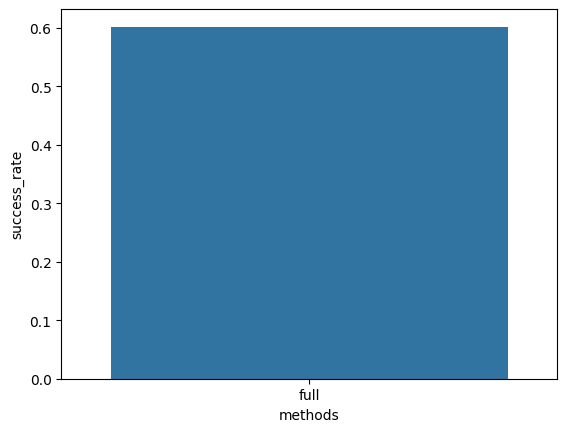

In [167]:
data = {
    "methods": ABLATIONS,
    "success_rate": success_rate_list,
}

seaborn.barplot(x="methods", y="success_rate", data=data)

<Axes: xlabel='methods', ylabel='avg_visibility_perc'>

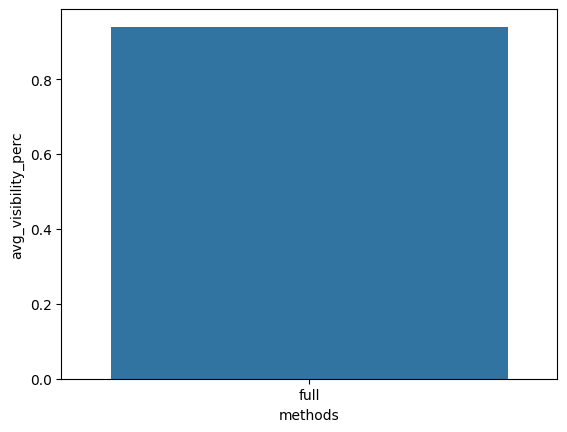

In [169]:
data = {
    "methods": ABLATIONS,
    "avg_visibility_perc": avg_visibility_perc_list,
}

seaborn.barplot(x="methods", y="avg_visibility_perc", data=data)